In [1]:
%load_ext autotime

import scarf
import matplotlib.pyplot as plt
import pandas as pd

scarf.__version__

'1.0.0'

time: 2.16 s (started: 2026-07-17 01:32:02 +02:00)


In [2]:
scarf.fetch_dataset("lecun_60K_mnist_images", save_path="scarf_datasets")

time: 24.5 s (started: 2026-07-17 01:32:04 +02:00)


In [3]:
reader = scarf.CrDirReader("scarf_datasets/lecun_60K_mnist_images")
writer = scarf.CrToZarr(
    reader,
    zarr_loc="scarf_datasets/lecun_60K_mnist_images/data.zarr",
    chunk_size=(2000, 1000),
)
writer.dump(batch_size=1000)

feature_types extraction failed from features.tsv.gz in column 2



Writing countsT shape=(784, 60000) chunks=(784, 60000)



time: 51.7 s (started: 2026-07-17 01:32:27 +02:00)


In [4]:
ds = scarf.DataStore(
    "scarf_datasets/lecun_60K_mnist_images/data.zarr",
    min_cells_per_feature=1000,
    min_features_per_cell=10,
    nthreads=4,
)
ds

No matches found for pattern MT-|mt. Will not add/update percentage feature



No matches found for pattern RPS|RPL|MRPS|MRPL. Will not add/update percentage feature



DataStore has 60000 (60000) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_nFeatures', 'RNA_nCounts', 
          
   RNA assay has 467 (784) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          

time: 1.23 s (started: 2026-07-17 01:33:17 +02:00)


In [5]:
ds.cells.insert(
    "digit_label",
    [int(x.rsplit("_", 1)[-1]) - 1 for x in ds.cells.fetch_all("names")],
    overwrite=True,
)

time: 58 ms (started: 2026-07-17 01:33:18 +02:00)


make_graph step 1/7: normalize expression matrix (computing)



make_graph step 1/7: normalize expression matrix finished in 1.5s (computing)



make_graph step 2/7: normalization statistics (computing)



make_graph step 2/7: normalization statistics finished in 0.4s (computing)



make_graph step 3/7: dimension reduction, ANN index, and kmeans (computing)



...

make_graph step 6/7: smooth KNN distances into graph (computing)



make_graph step 6/7: smooth KNN distances into graph finished in 18.5s (computing)



ANN recall: 100.00%



make_graph step 7/7: finalize graph metadata (computing)



make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)



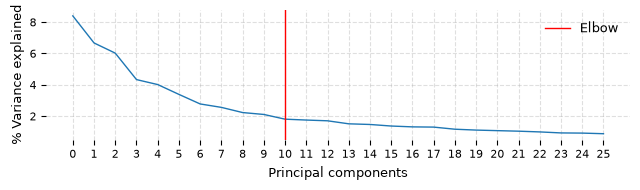

make_graph finished in 36.4s (7/7 steps, 36.0s in logged steps)



time: 36.4 s (started: 2026-07-17 01:33:18 +02:00)


In [6]:
# Set normalization method to a dummy function that returns unnormalized data
ds.RNA.normMethod = scarf.assay.norm_dummy

ds.make_graph(feat_key="I", k=31, dims=25, n_centroids=100, show_elbow_plot=True)

In [7]:
ds.run_umap(n_epochs=300, spread=1, min_dist=0.05, parallel=True)

Training UMAP:   0%|                                                                                          …

time: 42.7 s (started: 2026-07-17 01:33:53 +02:00)


In [8]:
ds.run_clustering(n_clusters=20)

time: 14.3 s (started: 2026-07-17 01:34:32 +02:00)


In [9]:
ds.smart_label(
    to_relabel="RNA_cluster",
    base_label="digit_label",
    new_col_name="cluster_label",
)

time: 119 ms (started: 2026-07-17 01:34:46 +02:00)


/home/parashar/scarf/scarf/plots.py:1032: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


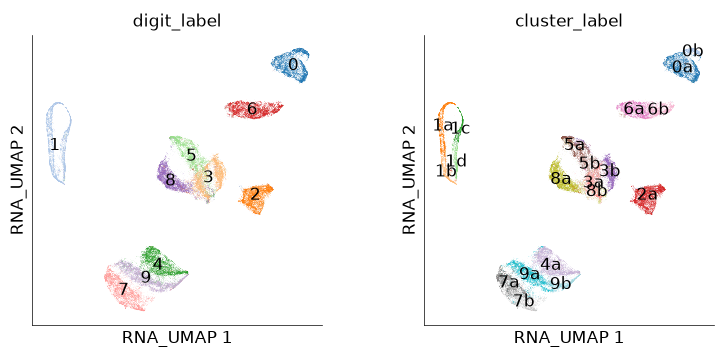

time: 2.56 s (started: 2026-07-17 01:34:47 +02:00)


In [10]:
ds.plot_layout(
    layout_key="RNA_UMAP",
    color_by=["digit_label", "cluster_label"],
    do_shading=True,
    shade_npixels=300,
    legend_onside=False,
    width=4,
    height=4,
    cmap="tab20",
)

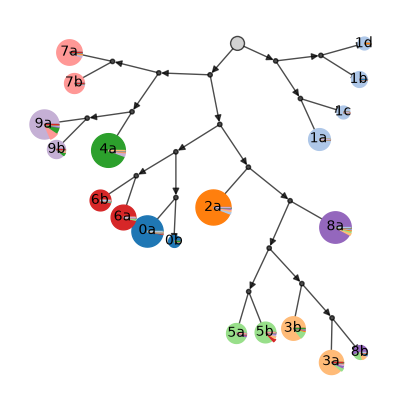

time: 2.74 s (started: 2026-07-17 01:34:49 +02:00)


In [11]:
ds.plot_cluster_tree(
    cluster_key="cluster_label",
    fill_by_value="digit_label",
)

In [12]:
clusts = pd.Series(ds.cells.fetch_all("cluster_label"))
digits = pd.Series(ds.cells.fetch_all("digit_label"))

time: 54.6 ms (started: 2026-07-17 01:34:52 +02:00)


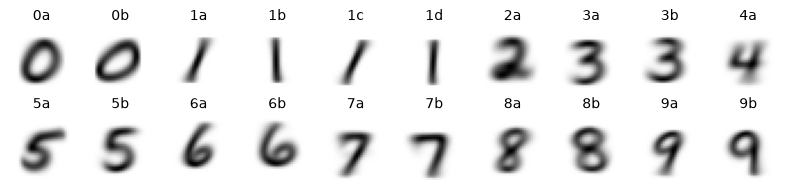

time: 6.96 s (started: 2026-07-17 01:34:52 +02:00)


In [13]:
fig = plt.figure(figsize=(8, 2))
for n, i in enumerate(sorted(clusts.unique())):
    mean_map = ds.RNA.rawData[((clusts == i) & (digits == int(i[0]))).values].mean(
        axis=0
    )
    mean_map = mean_map.compute().reshape(28, 28)
    ax = fig.add_subplot(2, 10, n + 1)
    ax.imshow(mean_map, cmap="binary")
    ax.set_axis_off()
    ax.set_title(i, fontsize=10)
plt.tight_layout()
plt.show()